In [1]:
# aperiodic: uses_preview_data

# Alpha Discovery with Market Microstructure
#
This notebook extends the alpha-discovery workflow by searching two dimensions:
rank-window normalization and moving-average smoothing.

Each feature is converted into a rolling percentile-rank signal, then optionally
smoothed with a short moving average to reduce noise before evaluating the next-bar
return relationship and a simple position backtest.

In [2]:

from __future__ import annotations

import datetime
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from aperiodic import get_derivative_metrics, get_metrics, get_ohlcv
from utils._aperiodic_demo import run_position_backtest

SYMBOL = "perpetual-BTC-USDT:USDT"
EXCHANGE = "binance-futures"
INTERVAL = "5m"
TIMESTAMP = "exchange"  # local timestamp or "true"

START_DATE = datetime.date(2025, 5, 1)
END_DATE = datetime.date(2025, 5, 31)

METRICS = [
    ("basis", "derivative"),
    ("funding", "derivative"),
    ("open_interest", "derivative"),
    ("flow", "regular"),
    ("impact", "regular"),
    # ("l1_imbalance", "regular"),
    # ("l1_liquidity", "regular"),
    # ("l2_imbalance", "regular"),
    # ("l2_liquidity", "regular"),
    ("returns", "regular"),
    ("slippage", "regular"),
    ("trade_size", "regular"),
    ("updownticks", "regular"),
    ("run_structure", "regular"),
    ("vtwap", "regular"),
    ("range", "regular"),
]

RANK_WINDOWS = [100, 300, 600, 1200, 2400]
SMOOTH_WINDOWS = [None, 10, 50, 100, 200, 400]
COST_BPS = 1.0

API_KEY = "..."  # Set via APERIODIC_API_KEY env var or .env file
if API_KEY == "...":
    API_KEY = os.getenv("APERIODIC_API_KEY", "...")
if API_KEY == "...":
    raise RuntimeError("Set APERIODIC_API_KEY in the environment or in .env.")


def get_numeric_metric_frame(metric: str, kind: str) -> pd.DataFrame | None:
    fetcher = get_derivative_metrics if kind == "derivative" else get_metrics
    raw_df = fetcher(
        api_key=API_KEY,
        metric=metric,
        timestamp=TIMESTAMP,
        interval=INTERVAL,
        exchange=EXCHANGE,
        symbol=SYMBOL,
        start_date=START_DATE,
        end_date=END_DATE,
        output="pandas",
        show_progress=True,
        preview=True,
    )

    df = raw_df.to_pandas() if hasattr(raw_df, "to_pandas") else pd.DataFrame(raw_df)

    if df.empty or "time" not in df.columns:
        print(f"Skipping {metric}: no rows returned.")
        return None

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if "time" in numeric_cols:
        numeric_cols.remove("time")

    if not numeric_cols:
        print(f"Skipping {metric}: no numeric columns returned.")
        return None

    return df.sort_values("time").drop_duplicates(subset=["time"], keep="last")[
        ["time", *numeric_cols]
    ]


def build_panel() -> tuple[pd.DataFrame, list[str]]:
    raw_ohlcv = get_ohlcv(
        api_key=API_KEY,
        timestamp=TIMESTAMP,
        interval=INTERVAL,
        exchange=EXCHANGE,
        symbol=SYMBOL,
        start_date=START_DATE,
        end_date=END_DATE,
        output="pandas",
        show_progress=True,
        preview=True,
    )

    panel = (
        raw_ohlcv.to_pandas() if hasattr(raw_ohlcv, "to_pandas") else pd.DataFrame(raw_ohlcv)
    )
    panel = panel.sort_values("time")[["time", "close"]]

    for metric, kind in METRICS:
        frame = get_numeric_metric_frame(metric, kind)
        if frame is None:
            continue

        numeric_feature_cols = [col for col in frame.columns if col != "time"]
        if frame[numeric_feature_cols].notna().sum().sum() == 0:
            print(f"Skipping {metric}: all feature values are null.")
            continue

        panel = panel.merge(frame, on="time", how="left")

    panel = panel.sort_values("time")
    feature_cols = [
        col
        for col in panel.columns
        if col not in {"time", "close"}
        and pd.api.types.is_numeric_dtype(panel[col])
    ]

    panel[feature_cols] = panel[feature_cols].ffill()
    panel["fwd_ret"] = panel["close"].pct_change().shift(-1)
    panel = panel.dropna(subset=["fwd_ret"])

    print(f"Panel built: {len(panel)} rows. Found {len(feature_cols)} features.")
    return panel, feature_cols


def make_rank_signal(panel_df: pd.DataFrame, feature: str, window: int) -> np.ndarray:
    rank = panel_df[feature].rolling(window).rank(method="average")
    signal = ((rank - 1.0) / (window - 1)) * 2.0 - 1.0
    return signal.to_numpy().astype(np.float64)


def smooth_signal(signal: np.ndarray, window: int | None) -> np.ndarray:
    if window is None or pd.isna(window) or int(window) == 1:
        return signal.astype(np.float64, copy=True)

    normalized_window = int(window)
    return (
        pd.Series(signal)
        .rolling(normalized_window)
        .mean()
        .to_numpy()
        .astype(np.float64)
    )


panel, feature_cols = build_panel()

print(f"Rows: {len(panel):,}")
print(f"Features: {feature_cols}")
print(panel.head())

Panel built: 8927 rows. Found 129 features.
Rows: 8,927
Features: ['basis', 'basis_bps', 'mark_price_spread', 'mark_price_spread_bps', 'basis_mean', 'basis_bps_std', 'mark_price_spread_mean', 'mark_price_spread_bps_std', 'funding_rate', 'funding_rate_update_frequency', 'funding_rate_avg_update_interval', 'open_interest', 'open_interest_pct_change', 'open_interest_volatility', 'oi_price_change_ratio', 'taker_buy_volume', 'taker_sell_volume', 'taker_buy_count', 'taker_sell_count', 'volume_delta', 'volume_delta_notional', 'flow_entropy', 'flow_toxicity_score', 'taker_buy_sell_ratio', 'taker_buy_sell_count_ratio', 'taker_buy_sell_percentage', 'taker_buy_sell_count_percentage', 'taker_buy_small_order_volume', 'taker_buy_small_order_count', 'taker_buy_medium_order_volume', 'taker_buy_medium_order_count', 'taker_buy_large_order_volume', 'taker_buy_large_order_count', 'taker_sell_small_order_volume', 'taker_sell_small_order_count', 'taker_sell_medium_order_volume', 'taker_sell_medium_order_cou

/tmp/ipykernel_2429/1257202686.py:125: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  panel["fwd_ret"] = panel["close"].pct_change().shift(-1)


In [3]:
# Evaluate each feature across rank windows and smoothing windows.
forward_returns = panel["fwd_ret"].to_numpy().astype(np.float64)
results = []

for feature in feature_cols:
    for rank_window in RANK_WINDOWS:
        raw_signal = make_rank_signal(panel, feature, rank_window)

        for smooth_window in SMOOTH_WINDOWS:
            signal = smooth_signal(raw_signal, smooth_window)
            mask = np.isfinite(signal) & np.isfinite(forward_returns)

            signal_valid = signal[mask]
            returns_valid = forward_returns[mask]
            if (
                signal_valid.size < 2
                or np.std(signal_valid) == 0.0
                or np.std(returns_valid) == 0.0
            ):
                continue

            fit_corr = float(np.corrcoef(signal_valid, returns_valid)[0, 1])
            if not np.isfinite(fit_corr):
                continue

            direction = 1 if fit_corr >= 0 else -1
            _, bt_summary = run_position_backtest(
                timestamps=panel.loc[mask, "time"],
                position=np.nan_to_num(
                    np.clip(signal_valid * direction, -1.0, 1.0), nan=0.0
                ),
                forward_return=returns_valid,
                cost_bps_one_way=COST_BPS,
            )

            results.append(
                {
                    "feature": feature,
                    "rank_window": rank_window,
                    "smooth_window": smooth_window,
                    "direction": direction,
                    "fit_corr": fit_corr,
                    "sharpe": bt_summary["annualized_sharpe"],
                    "total_return": bt_summary["net_return_pct"],
                    "max_drawdown": bt_summary["max_drawdown_pct"],
                }
            )

if not results:
    raise RuntimeError(
        "No valid feature/window combinations were produced. "
        "Check the fetched metric coverage for the selected date range."
    )

results_df = pd.DataFrame(results).sort_values("sharpe", ascending=False)
print(results_df.head(50).to_markdown(index=False))

| feature                           |   rank_window |   smooth_window |   direction |   fit_corr |   sharpe |   total_return |   max_drawdown |
|:----------------------------------|--------------:|----------------:|------------:|-----------:|---------:|---------------:|---------------:|
| price_kurtosis                    |          2400 |             200 |          -1 | -0.0301028 |  7.86532 |       0.688764 |     -0.135004  |
| volume_delta_notional             |          1200 |             100 |          -1 | -0.0336731 |  7.75412 |       1.15405  |     -0.240235  |
| volume_delta                      |          1200 |             100 |          -1 | -0.0336114 |  7.72586 |       1.14757  |     -0.240183  |
| downtick_count_percentage         |          1200 |             200 |           1 |  0.0245554 |  7.69932 |       3.2125   |     -0.798634  |
| taker_buy_sell_percentage         |          1200 |             400 |          -1 | -0.025119  |  7.54745 |       0.566899 |     -0.17

## Takeaways

Moving-average smoothing adds a second degree of freedom to the alpha search.
Short smoothing windows can suppress microstructure noise, while longer windows
can expose more persistent order-flow or positioning regimes.

Best Strategy found:
{'feature': 'price_kurtosis', 'rank_window': 2400, 'smooth_window': 200.0, 'direction': -1, 'fit_corr': -0.030102819259242377, 'sharpe': 7.865321648511961, 'total_return': 0.6887638878810165, 'max_drawdown': -0.13500400128088258}


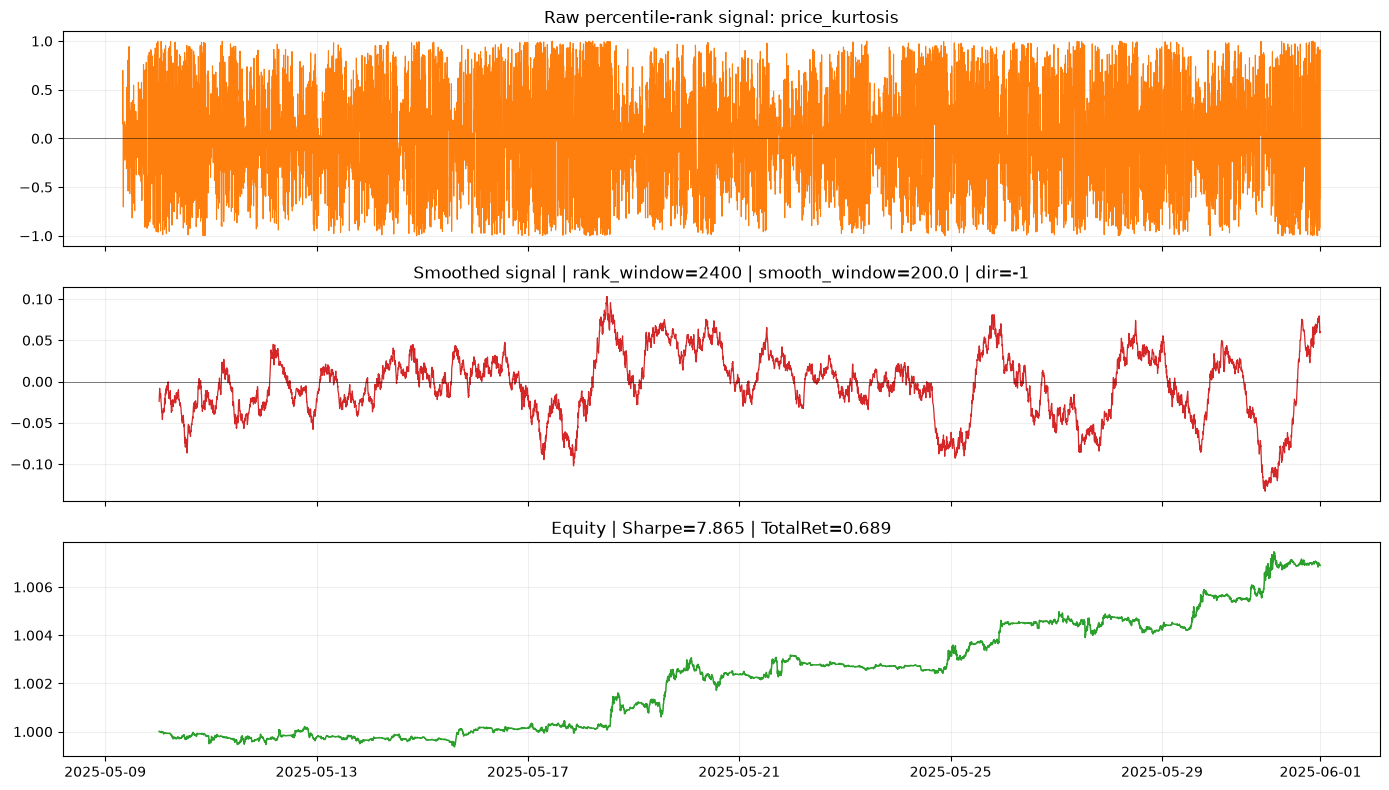

In [4]:
best = results_df.iloc[0].to_dict()
best_feature = str(best["feature"])
best_rank_window = int(best["rank_window"])
best_smooth_window = best["smooth_window"]
best_direction = int(best["direction"])

best_smooth_window_label = (
    "None" if best_smooth_window is None or pd.isna(best_smooth_window) else best_smooth_window
)

raw_signal = make_rank_signal(panel, best_feature, best_rank_window)
signal = smooth_signal(raw_signal, best_smooth_window) * best_direction

mask = np.isfinite(signal) & np.isfinite(forward_returns)
bt_frame, bt_summary = run_position_backtest(
    timestamps=panel.loc[mask, "time"],
    position=np.nan_to_num(np.clip(signal[mask], -1.0, 1.0), nan=0.0),
    forward_return=forward_returns[mask],
    cost_bps_one_way=COST_BPS,
)
equity = bt_frame["equity_curve"]

print("Best Strategy found:")
print(best)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axes[0].plot(panel["time"], raw_signal, linewidth=0.8, color="tab:orange")
axes[0].axhline(0.0, color="black", linewidth=0.7, alpha=0.5)
axes[0].set_title(f"Raw percentile-rank signal: {best_feature}")
axes[0].grid(alpha=0.2)

axes[1].plot(panel["time"], signal, linewidth=0.9, color="tab:red")
axes[1].axhline(0.0, color="black", linewidth=0.7, alpha=0.5)
axes[1].set_title(
    "Smoothed signal"
    f" | rank_window={best_rank_window}"
    f" | smooth_window={best_smooth_window_label}"
    f" | dir={best_direction}"
)
axes[1].grid(alpha=0.2)

axes[2].plot(bt_frame["timestamp"], equity, linewidth=1.1, color="tab:green")
axes[2].set_title(
    f"Equity | Sharpe={best['sharpe']:.3f} | TotalRet={best['total_return']:.3f}"
)
axes[2].grid(alpha=0.2)

fig.tight_layout()
plt.show()

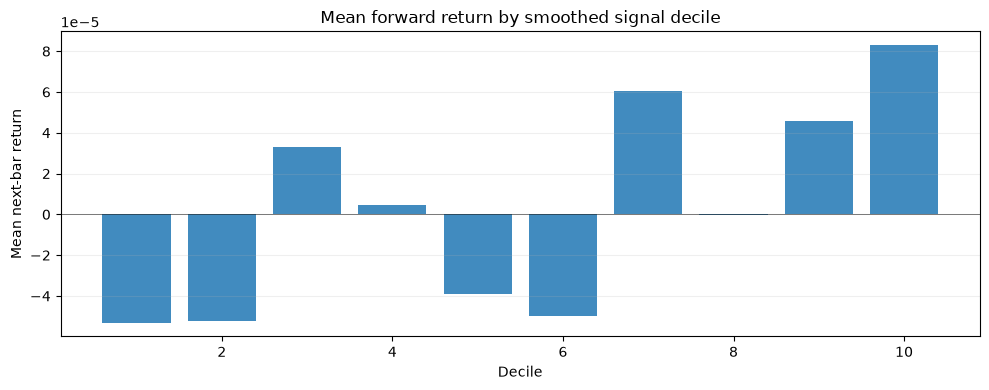

   decile  count  mean_signal  mean_fwd_ret
0       1    633    -0.081439 -5.307633e-05
1       2    633    -0.046031 -5.221500e-05
2       3    633    -0.029194  3.306550e-05
3       4    633    -0.017847  4.461195e-06
4       5    633    -0.007287 -3.881279e-05
5       6    633     0.003153 -4.990369e-05
6       7    633     0.012779  6.043717e-05
7       8    633     0.022608 -3.008536e-07
8       9    633     0.036939  4.582411e-05
9      10    632     0.060338  8.292948e-05


In [5]:
mask = np.isfinite(signal) & np.isfinite(forward_returns)
signal_valid = signal[mask]
returns_valid = forward_returns[mask]

if signal_valid.size == 0:
    raise RuntimeError("Best strategy produced no valid observations for decile analysis.")

order = np.argsort(signal_valid)
deciles = np.empty(signal_valid.shape[0], dtype=np.int64)
deciles[order] = (np.arange(signal_valid.shape[0]) * 10 // signal_valid.shape[0]) + 1

deciles_df = pd.DataFrame(
    [
        {
            "decile": decile,
            "count": int((decile_mask := deciles == decile).sum()),
            "mean_signal": float(np.nanmean(signal_valid[decile_mask])),
            "mean_fwd_ret": float(np.nanmean(returns_valid[decile_mask])),
        }
        for decile in range(1, 11)
    ]
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(deciles_df["decile"], deciles_df["mean_fwd_ret"], color="tab:blue", alpha=0.85)
ax.axhline(0.0, color="black", linewidth=0.7, alpha=0.5)
ax.set_title("Mean forward return by smoothed signal decile")
ax.set_xlabel("Decile")
ax.set_ylabel("Mean next-bar return")
ax.grid(alpha=0.2, axis="y")
fig.tight_layout()
plt.show()

print(deciles_df)

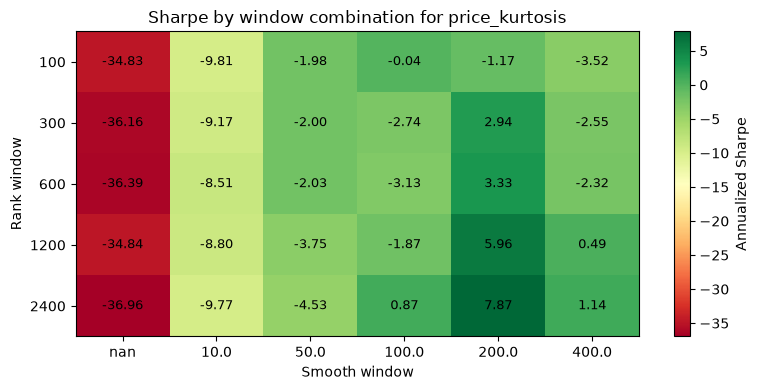

In [6]:
best_feature_results = results_df.loc[
    results_df["feature"] == best_feature,
    ["rank_window", "smooth_window", "sharpe"],
].copy()
heatmap = best_feature_results.pivot(
    index="rank_window", columns="smooth_window", values="sharpe"
).sort_index()

heatmap = heatmap.rename(columns={None: "None"})

fig, ax = plt.subplots(figsize=(8, 4))
image = ax.imshow(heatmap.to_numpy(), aspect="auto", cmap="RdYlGn")
ax.set_title(f"Sharpe by window combination for {best_feature}")
ax.set_xlabel("Smooth window")
ax.set_ylabel("Rank window")
ax.set_xticks(np.arange(len(heatmap.columns)), labels=heatmap.columns)
ax.set_yticks(np.arange(len(heatmap.index)), labels=heatmap.index)

for row_idx, row in enumerate(heatmap.to_numpy()):
    for col_idx, value in enumerate(row):
        ax.text(col_idx, row_idx, f"{value:.2f}", ha="center", va="center", fontsize=9)

fig.colorbar(image, ax=ax, label="Annualized Sharpe")
fig.tight_layout()
plt.show()

## Next Steps

- Compare whether smoothing improves stability out of sample or only in-sample fit.
- Re-run the search on longer date ranges and alternate venues to check persistence.
- Use the best-ranked smoothed signals as regime filters for broader strategies.

In [7]:
top_feature_summary = (
    results_df.groupby("feature", as_index=False)["sharpe"]
    .max()
    .sort_values("sharpe", ascending=False)
    .head(20)
)

print("Top 20 features by best Sharpe:")
print(top_feature_summary.to_markdown(index=False))

for feature in top_feature_summary["feature"]:
    feature_results = results_df.loc[
        results_df["feature"] == feature,
        ["rank_window", "smooth_window", "sharpe"],
    ].copy()
    feature_heatmap = feature_results.pivot(
        index="rank_window", columns="smooth_window", values="sharpe"
    ).sort_index()
    feature_heatmap = feature_heatmap.rename(columns={None: "None"})

    print(f"\nSharpe by window combination for {feature}:")
    print(feature_heatmap.to_markdown())

Top 20 features by best Sharpe:
| feature                           |   sharpe |
|:----------------------------------|---------:|
| price_kurtosis                    |  7.86532 |
| volume_delta_notional             |  7.75412 |
| volume_delta                      |  7.72586 |
| downtick_count_percentage         |  7.69932 |
| taker_buy_sell_percentage         |  7.54745 |
| taker_buy_sell_ratio              |  7.5474  |
| downtick_volume_percentage        |  7.43528 |
| unchanged_count_percentage        |  7.1726  |
| trade_amount_variance             |  6.69955 |
| trade_amount_std                  |  6.69955 |
| taker_buy_medium_order_percentage |  6.53048 |
| taker_sell_medium_order_count     |  6.40587 |
| taker_sell_volume                 |  6.38012 |
| taker_sell_large_order_volume     |  6.3796  |
| medium_order_percentage           |  6.33437 |
| slippage_bps_buy_sell_ratio       |  6.30844 |
| taker_sell_count                  |  6.24129 |
| open_interest_pct_change          |